# PV + CSP + BES + TES

A standalone microgrid demonstration. It uses 5% PNM demand, 3,000× PV availability, unscaled CSP, a 750 MWh / 150 MW battery, and 2,500 MWh-thermal / 150 MW TES.

In [1]:
from pathlib import Path
import sys
import pandas as pd

root = Path.cwd()
while not (root / 'enliten').is_dir():
    if root.parent == root: raise RuntimeError('Run from inside the ENLITEN repository.')
    root = root.parent
if str(root) not in sys.path: sys.path.insert(0, str(root))
from enliten import ChargingPath, Generation, LCOECalculator, Site, Storage, System
data_dir = root / 'examples' / 'data'

def profile(filename):
    frame = pd.read_csv(data_dir / filename)
    return pd.Series(frame['PNM'].to_numpy(float), index=pd.to_datetime(frame.iloc[:, 0], utc=True))

demand_full = profile('PNM_demand.csv')
pv_full = profile('PNM_pv_ac_1MW_av.csv')
csp_full = profile('PNM_csp_th_av.csv')
assert demand_full.index.equals(pv_full.index) and demand_full.index.equals(csp_full.index)

def build_system():
    # Use the complete aligned 2023 profiles for annual operational and LCOE results.
    load = (demand_full * 0.05).rename('load_MW')
    pv_multiplier, bes_capacity_MWh, bes_power_MW = 3_000.0, 750.0, 150.0
    tes_capacity_MWh_th, tes_power_MW_e = 2_500.0, 150.0
    pv_capex = pv_full.max() * pv_multiplier * 1_000 * 1_430
    pv_opex = pv_full.max() * pv_multiplier * 1_000 * 24
    bes_capex = bes_capacity_MWh * 1_000 * 300
    csp_tes_capex = tes_power_MW_e * 1_000 * 7_912
    site = Site('microgrid')
    csp = Generation('csp', site, csp_full, 'thermal', False, False, capex=csp_tes_capex, opex=tes_power_MW_e * 1_000 * 74.6)
    pv = Generation('pv', site, pv_full * pv_multiplier, 'electric', capex=pv_capex, opex=pv_opex)
    tes = Storage('tes', site, tes_capacity_MWh_th, tes_power_MW_e, 'thermal', 'electric', 0.50, maximum_stored_energy_rate_MW=300.0, variable_opex_USD_per_MWh=3.8)
    bes = Storage('bes', site, bes_capacity_MWh, bes_power_MW, 'electric', 'electric', 0.90, maximum_stored_energy_rate_MW=bes_power_MW, capex=bes_capex, opex=0.025 * bes_capex)
    paths = [ChargingPath('csp', 'tes', 'thermal', 'thermal', 0.90, 300.0 / 0.90), ChargingPath('pv', 'bes', 'electric', 'electric', 0.90, bes_power_MW / 0.90)]
    return System(load, [tes, csp, bes, pv], paths)

system = build_system()
system.timeseries.head(24)

,load_MW,grid_to_load_MWh_electric,unmet_load_MWh_electric,export_energy_MWh_electric,csp_available_MW_thermal,csp_to_load_MWh_electric,csp_to_grid_MWh_electric,csp_curtailed_MWh_thermal,pv_available_MW_electric,pv_to_load_MWh_electric,...,csp_to_tes_stored_MWh_thermal,pv_to_bes_MWh_electric,pv_to_bes_stored_MWh_electric,tes_MWh_thermal,tes_to_load_MWh_electric,tes_loss_MWh_thermal,bes_MWh_electric,bes_to_load_MWh_electric,bes_loss_MWh_electric,microgrid_POI_MW_electric
date_time,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00+00:00,84.48,0.00,0.0,0.0,0.000000,0.0,0.0,0.0,0.158849,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.00
2023-01-01 01:00:00+00:00,91.86,91.86,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.00
2023-01-01 02:00:00+00:00,92.71,92.71,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.00
2023-01-01 03:00:00+00:00,91.48,91.48,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.00
2023-01-01 04:00:00+00:00,90.35,90.35,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.00
2023-01-01 05:00:00+00:00,88.59,88.59,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.00
2023-01-01 06:00:00+00:00,86.17,86.17,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.00
2023-01-01 07:00:00+00:00,83.79,83.79,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.00
2023-01-01 08:00:00+00:00,81.62,81.62,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.00


In [2]:
system.operation_metrics()

{'operating_hours': 8759,
 'load_MWh_electric': 714158.81,
 'generation_to_load_MWh_electric': 305903.8760946745,
 'storage_to_load_MWh_electric': 392988.79030566604,
 'system_to_load_MWh_electric': 698892.6664003406,
 'grid_to_load_MWh_electric': 15266.14359965943,
 'unmet_load_MWh_electric': 0.0,
 'export_energy_MWh_electric': 125003.0586622025,
 'percent_load_met': 99.99999999999999,
 'percent_load_by_system': 97.86236011011901,
 'system_capex_USD': 1627380965.554332,
 'system_annual_OM_USD': 20433142.079233542,
 'csp_curtailed_MWh_thermal': 291175.1434863787,
 'pv_curtailed_MWh_electric': 0.0,
 'load_annual_MWh_electric': [714240.3442858774],
 'system_to_load_annual_MWh_electric': [698972.4577767991],
 'grid_to_load_annual_MWh_electric': [15267.886509078275],
 'export_energy_annual_MWh_electric': [125017.33004691105],
 'annual_electricity_sales_USD': [0.0],
 'annual_electricity_purchases_USD': [0.0],
 'system_annual_VOM_USD': 1427634.0408689815,
 'system_augment_USD': [0.0],
 'syst

In [3]:
lcoe_metrics = LCOECalculator.from_system(system, analysis_period=30).calculate_lcoe_metrics()
lcoe_metrics

{'PVD': 0.767373270359498,
 'FCR_AT': 0.036148074230068654,
 'FCR_BT': 0.05294061134598742,
 'CRF': 0.07650022967642069,
 'NPV_cash_flow': -1475055027.0355105,
 'IRR': nan,
 'payback_period': None,
 'LCOE_real_USD_kWh_BT': 0.1667727497343313,
 'LCOE_real_USD_kWh_AT': 0.11649249351763317}

In [4]:
operating = system.timeseries.iloc[1:]
fully_served = operating['grid_to_load_MWh_electric'].lt(1e-9)
monthly_fully_served = 100 * fully_served.groupby(operating.index.month_name()).mean()
monthly_fully_served.reindex(['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']).round(1)

date_time
January       90.4
February      99.1
March        100.0
April        100.0
May          100.0
June         100.0
July         100.0
August       100.0
September    100.0
October      100.0
November      99.3
December      82.3
Name: grid_to_load_MWh_electric, dtype: float64

mkdir -p failed for path C:\Users\jenni\AppData\Local\matplotlib: [WinError 5] Access is denied: 'C:\\Users\\jenni\\AppData\\Local\\matplotlib'


Matplotlib created a temporary cache directory at C:\Users\jenni\AppData\Local\Temp\matplotlib-5fqk122f because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


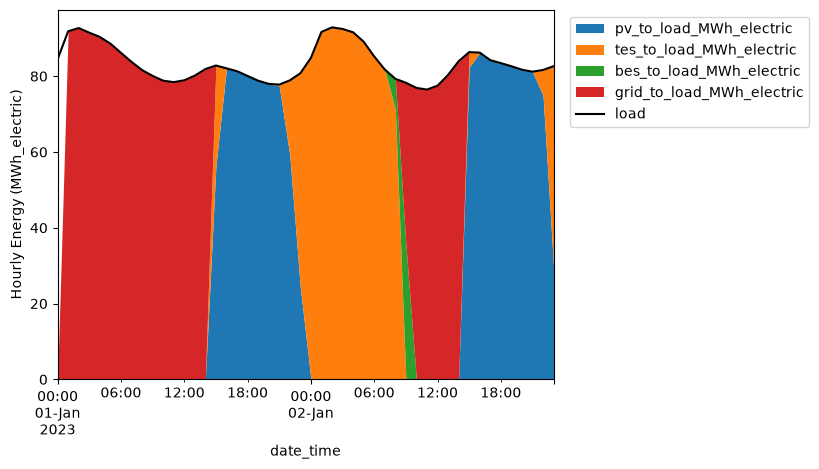

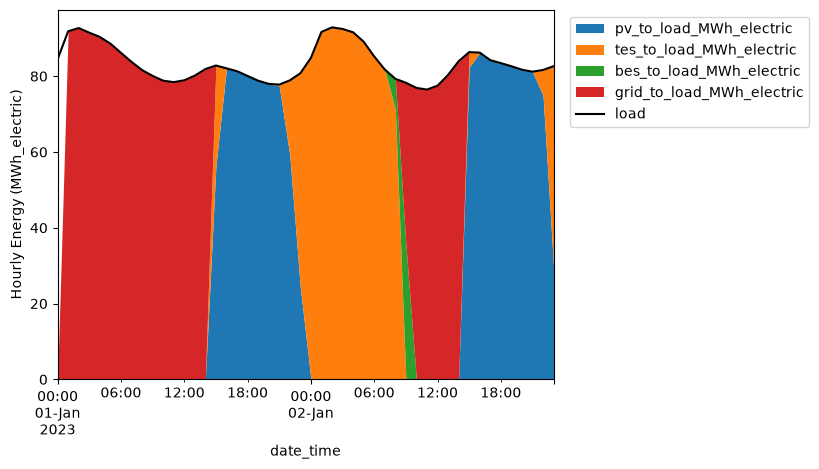

In [5]:
fig, ax = system.timeseries_plot_source(start_date=0, days=2)
fig

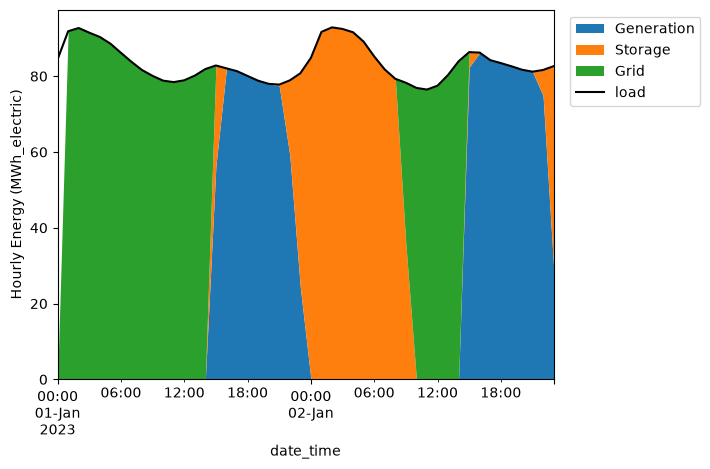

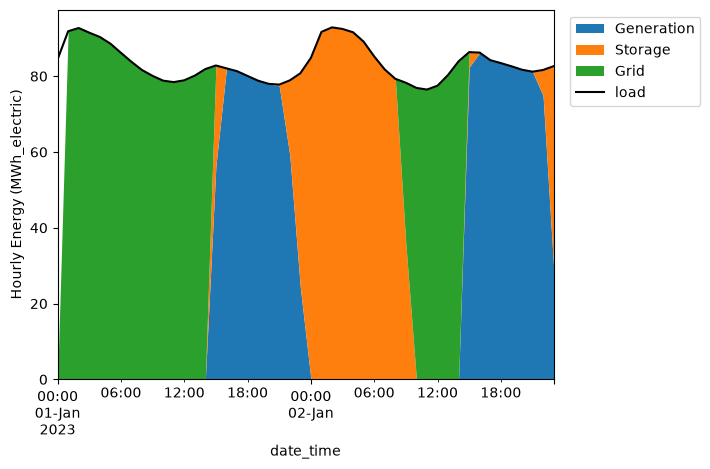

In [6]:
fig, ax = system.timeseries_plot_group(start_date=0, days=2)
fig

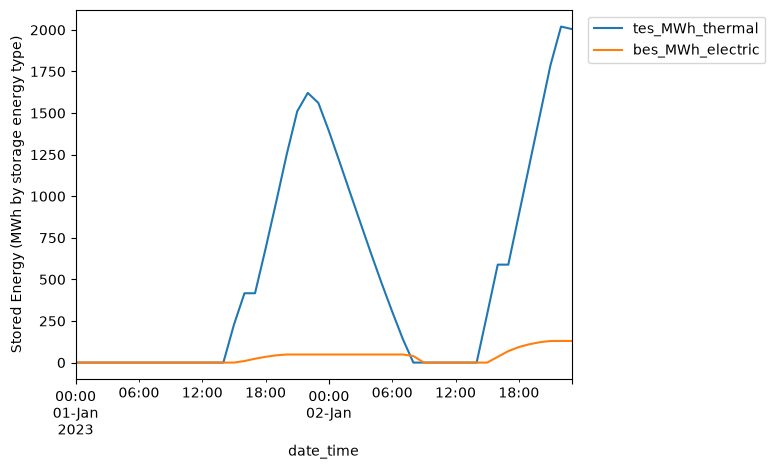

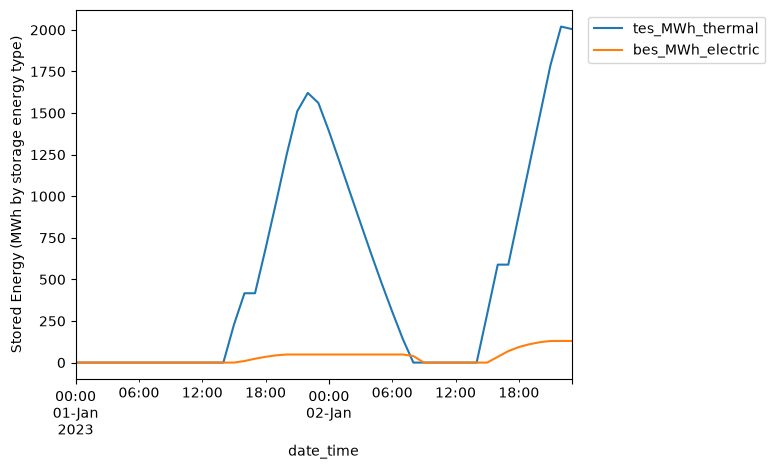

In [7]:
fig, ax = system.plot_storage_capacity(start_date=0, days=2)
fig

In [8]:
system.resilience_cases(critical_load_MW=20.0, target_hours=24, n_starts=20, seed=7)
system.resilience_summary

{'n_starts': 20,
 'pct_meets_actual': 95.0,
 'pct_meets_full': 100.0,
 'actual_reaches_end_pct': 95.0,
 'full_reaches_end_pct': 100.0,
 'tenth_pctile_actual_hrs': 24.0,
 'tenth_pctile_target_energy_actual_MWh_electric': 0.0,
 'tenth_pctile_target_energy_actual': 0.0,
 'tenth_pctile_pct_target_energy_actual': 100.0,
 'fiftieth_pctile_actual_hrs': 24.0,
 'fiftieth_pctile_target_energy_actual_MWh_electric': 0.0,
 'fiftieth_pctile_target_energy_actual': 0.0,
 'fiftieth_pctile_pct_target_energy_actual': 100.0,
 'ninetieth_pctile_actual_hrs': 24.0,
 'ninetieth_pctile_target_energy_actual_MWh_electric': 0.0,
 'ninetieth_pctile_target_energy_actual': 0.0,
 'ninetieth_pctile_pct_target_energy_actual': 100.0,
 'pct_meets_target_energy_actual': 95.0,
 'tenth_pctile_full_hrs': 24.0,
 'tenth_pctile_target_energy_full_MWh_electric': 0.0,
 'tenth_pctile_target_energy_full': 0.0,
 'tenth_pctile_pct_target_energy_full': 100.0,
 'fiftieth_pctile_full_hrs': 24.0,
 'fiftieth_pctile_target_energy_full_MWh_